In [1]:
import pandas as pd

In [2]:
# Load your preprocessed tweet data
tweets_df = pd.read_csv('CleanedSentiments.csv')

In [3]:
# Define a dictionary to map specific words to emojis
emoji_dict = {
    'win': '🏆',
    'gold': '🥇',
    'medal': '🏅',
    'champion': '👑',
    'congratulate': '🎉',
    'team': '👥',
    'game': '🎮',
    'world': '🌎',
    'record': '📈'
}

In [4]:
# Function to replace words in text with corresponding emojis
def text_to_emoji(text, emoji_dict):
    words = text.strip("[]").replace("'", "").split(", ")
    converted_text = ' '.join(emoji_dict.get(word, word) for word in words)
    return converted_text

In [5]:
print(tweets_df.columns)

Index(['Category', 'Keyword', 'Tweet_Timestamp', 'Tweet_Content',
       'Tweet_Number_of_Retweets', 'Tweet_Number_of_Likes',
       'Tweet_Number_of_Looks', 'Lemmatized_Tweets', 'Clean_Tweets'],
      dtype='object')


In [6]:
# Apply the function to each tweet
tweets_df['Cleaned_Tweet_Emojified'] = tweets_df['Clean_Tweets'].apply(lambda x: text_to_emoji(x, emoji_dict))

In [7]:
# Save or display the DataFrame with the new emoji column
print(tweets_df[['Clean_Tweets', 'Cleaned_Tweet_Emojified']].head())

                                        Clean_Tweets  \
0  ['olympic', 'legend', 'usabmnt', 'paris2024', ...   
1  ['olympicrecord', 'rizki', 'juniansyah', 'iwfn...   
2  ['men', 'javelin', 'throw', 'final', 'big', 'a...   
3  ['time', 'alive', 'usabmnt', 'paris2024', 'bas...   
4  ['quincy', 'hall', 'effort', 'stretch', 'win',...   

                             Cleaned_Tweet_Emojified  
0        olympic legend usabmnt paris2024 basketball  
1  olympicrecord rizki juniansyah iwfnet weightli...  
2  men javelin throw final big arshad nadeem neer...  
3            time alive usabmnt paris2024 basketball  
4  quincy hall effort stretch 🏆 olympic 🥇 deserve...  


In [8]:
# Define hate and non-hate keywords and emojis
hate_keywords = {
    'hate', 'anger', 'disgust', 'shame', 'mock', 'ruin', 'disrespect', 'dishonor',
    'fail', 'lose', 'disappoint', 'weak', 'cheat', 'unfair', 'corrupt', 'scam', 
    'boycott', 'ban', 'protest', 'controversy', 'biased', 'bad', 'terrible', 
    'awful', 'useless', 'overrated', 'waste', 'flop', 'loser', 'choker', 'fraud', 
    'pathetic', 'expensive', 'pollution', 'chaos'
}

In [9]:
non_hate_keywords = {'win', 'congrats', 'love', 'happy', 'excite', 'enjoy', 'amazing', 'proud'}

In [10]:
hate_emojis = {'😡', '😠', '👎', '💀'}
non_hate_emojis = {'😊', '🎉', '👍', '❤️', '🏆', '🥇'}

In [11]:
# Function to label tweets as hate or non-hate based on both text and emoji
def label_tweet(text):
    # Convert text to lowercase for consistent matching
    text = text.lower()
    
    # Check for any hate keywords or emojis
    hate_present = any(keyword in text for keyword in hate_keywords) or any(emoji in text for emoji in hate_emojis)
    non_hate_present = any(keyword in text for keyword in non_hate_keywords) or any(emoji in text for emoji in non_hate_emojis)
    
    # Label based on presence of hate indicators
    if hate_present:
        return 'hate'
    elif non_hate_present:
        return 'non-hate'
    else:
        # Default to non-hate if no strong indicators
        return 'non-hate'

In [12]:
# Apply the labeling function to the 'Cleaned_Tweet_Emojified' column in tweets_df
tweets_df['Label'] = tweets_df['Cleaned_Tweet_Emojified'].apply(label_tweet)

In [13]:
# Display the first few rows to verify
tweets_df[['Cleaned_Tweet_Emojified', 'Label']].head()

,Cleaned_Tweet_Emojified,Label
0,olympic legend usabmnt paris2024 basketball,non-hate
1,olympicrecord rizki juniansyah iwfnet weightli...,non-hate
2,men javelin throw final big arshad nadeem neer...,non-hate
3,time alive usabmnt paris2024 basketball,non-hate
4,quincy hall effort stretch 🏆 olympic 🥇 deserve...,non-hate


In [14]:
# Save the labeled data to a new CSV file
tweets_df.to_csv('Labeled_Olympics_Paris_2024_Tweets.csv', index=False)

In [15]:
import nltk
import gensim.downloader as api
import emoji
from sklearn.feature_extraction.text import CountVectorizer
from textblob import TextBlob
import numpy as np

In [16]:
# Load the GloVe model from gensim
glove_model = api.load("glove-wiki-gigaword-50")

In [17]:
# Step 1: Define feature extraction functions

# Word Embedding Function
def get_word_embedding(tweet, model=glove_model):
    words = nltk.word_tokenize(tweet)
    embedding = [model[word] for word in words if word in model]
    if embedding:
        return np.mean(embedding, axis=0)  # Average the word embeddings
    else:
        return np.zeros(50)  # Return zero vector if no words found in model

In [18]:
# Sentiment Score Function
def get_sentiment_score(tweet):
    blob = TextBlob(tweet)
    return blob.sentiment.polarity  # Ranges from -1 (negative) to 1 (positive)

In [19]:
# Emoji Embedding Function
def get_emoji_embedding(tweet, model=glove_model):
    emojis_in_tweet = [ch for ch in tweet if emoji.is_emoji(ch)]
    embedding = [model[emoji.demojize(e).replace(":", "")] for e in emojis_in_tweet if emoji.demojize(e).replace(":", "") in model]
    if embedding:
        return np.mean(embedding, axis=0)  # Average the emoji embeddings
    else:
        return np.zeros(50)  # Return zero vector if no emoji embeddings found

In [20]:
# Step 2: Apply the functions to `tweets_df`
# Apply word embeddings, sentiment scores, and emoji embeddings
tweets_df['Word_Embedding'] = tweets_df['Cleaned_Tweet_Emojified'].apply(get_word_embedding)

In [21]:
tweets_df['Sentiment_Score'] = tweets_df['Cleaned_Tweet_Emojified'].apply(get_sentiment_score)

In [22]:
tweets_df['Emoji_Embedding'] = tweets_df['Cleaned_Tweet_Emojified'].apply(get_emoji_embedding)

In [23]:
# Step 3: Generate Bigrams
# Using CountVectorizer to extract bigrams (2-grams) for all tweets in the DataFrame
vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=10000)  # Adjust max_features as needed
X_bigrams = vectorizer.fit_transform(tweets_df['Cleaned_Tweet_Emojified'])

In [24]:
# Store bigram features in a DataFrame, which you can join back to `tweets_df`
bigrams_df = pd.DataFrame.sparse.from_spmatrix(X_bigrams, columns=vectorizer.get_feature_names_out())
tweets_df = pd.concat([tweets_df.reset_index(drop=True), bigrams_df.reset_index(drop=True)], axis=1)

In [25]:
# Step 4: Display the modified DataFrame with extracted features
tweets_df[['Cleaned_Tweet_Emojified', 'Label', 'Word_Embedding', 'Sentiment_Score', 'Emoji_Embedding'] + list(bigrams_df.columns)].head()

,Cleaned_Tweet_Emojified,Label,Word_Embedding,Sentiment_Score,Emoji_Embedding,aap mp,aaron brook,abad que,abhi bhi,abhinavbindra tweeted,...,zheng qinwen,zhihui defended,zhou yaqin,zhouyaqin captured,zhouyaqin olympics2024,ziad el,zii jiaolympic,zimbabwe hmetro,zimbabwe olympic,zro il
0,olympic legend usabmnt paris2024 basketball,non-hate,"[-1.2715901, 1.4952334, -0.48062864, 1.1680133...",0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,olympicrecord rizki juniansyah iwfnet weightli...,non-hate,"[-0.67038995, 0.25343665, -0.118769996, 0.5719...",0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,men javelin throw final big arshad nadeem neer...,non-hate,"[-0.72372204, 0.24229102, 0.123919986, 0.36364...",0.0,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,time alive usabmnt paris2024 basketball,non-hate,"[-0.5933667, 0.5542213, -0.008117666, 0.185876...",0.1,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,quincy hall effort stretch 🏆 olympic 🥇 deserve...,non-hate,"[-0.3588067, 0.7533684, -0.14028433, 0.1495631...",0.0,"[-0.8267, 1.0863, -0.39731, 1.0596, 0.20089, 0...",0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.cluster import DBSCAN
from sklearn.metrics import classification_report, confusion_matrix

In [27]:
# Step 1: Add emoji features to the DataFrame
tweets_df['hate_emoji'] = tweets_df['Clean_Tweets'].apply(lambda x: 1 if any(emoji in x for emoji in hate_emojis) else 0)
tweets_df['non_hate_emoji'] = tweets_df['Clean_Tweets'].apply(lambda x: 1 if any(emoji in x for emoji in non_hate_emojis) else 0)

In [28]:
# Step 2: Convert 'Word_Embedding' to a consistent 2D numpy array
X = np.array([np.array(embedding) for embedding in tweets_df['Word_Embedding']])

In [29]:
# Step 3: Add emoji features to the word embeddings
X_emoji_features = tweets_df[['hate_emoji', 'non_hate_emoji']].values  # Extract emoji columns
X_combined = np.concatenate([X, X_emoji_features], axis=1)  # Combine word embeddings and emoji features

In [30]:
# Verify the shape of the combined data
print("Shape of X_combined before clustering:", X_combined.shape)

Shape of X_combined before clustering: (29464, 52)


In [31]:
# Step 4: Apply DBSCAN clustering to the word embeddings (X_combined)
eps_value = 0.5  # Maximum distance between points to be considered neighbors
min_samples_value = 5  # Minimum number of points required to form a cluster

In [32]:
# DBSCAN clustering
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
X_clustered = dbscan.fit_predict(X_combined)  # This gives cluster labels or -1 for noise points

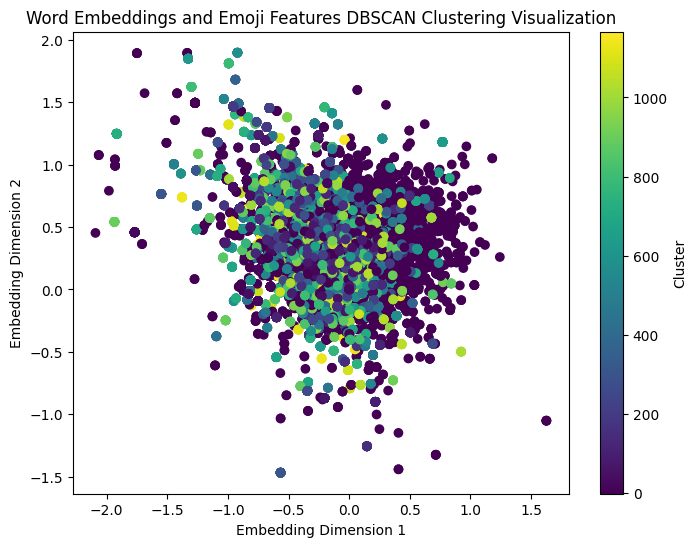

In [33]:
# Visualize the clustering results (first 2 dimensions for plotting)
plt.figure(figsize=(8, 6))
plt.scatter(X_combined[:, 0], X_combined[:, 1], c=X_clustered, cmap='viridis')
plt.colorbar(label='Cluster')
plt.title("Word Embeddings and Emoji Features DBSCAN Clustering Visualization")
plt.xlabel("Embedding Dimension 1")
plt.ylabel("Embedding Dimension 2")
plt.show()

In [34]:
# Print DBSCAN cluster labels
print("DBSCAN Cluster Labels:\n", X_clustered)

DBSCAN Cluster Labels:
 [  0   1   2 ... 232 212 124]


In [35]:
# Reshape the clustered labels to match the LSTM input format
X_clustered = X_clustered.reshape((X_clustered.shape[0], 1, 1))  # Reshape to (samples, timesteps, features)

In [36]:
# Step 5: Prepare the labels for classification
label_encoder = LabelEncoder()
y = tweets_df['Label']
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded) 

In [37]:
# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_clustered, y_categorical, test_size=0.2, random_state=42)

In [38]:
# Step 6: Define the LSTM model
input_layer = Input(shape=(X_clustered.shape[1], X_clustered.shape[2]))  # Input layer

In [39]:
# LSTM layer
lstm_out = LSTM(64, return_sequences=False)(input_layer)  # LSTM layer with 64 units

In [40]:
# Dropout layer
lstm_out = Dropout(0.5)(lstm_out)

In [41]:
# Dense layer with ReLU activation
dense_out = Dense(32, activation='relu')(lstm_out)

In [42]:
# Output layer for binary classification
output_layer = Dense(2, activation='softmax')(dense_out)

In [43]:
# Define the model
model = Model(inputs=input_layer, outputs=output_layer)

In [44]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [45]:
# Print model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 1, 1)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ (None, 64)                  │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,042 (74.38 KB)

 Trainable params: 19,042 (74.38 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
# Step 7: Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9297 - loss: 0.2816 - val_accuracy: 0.9387 - val_loss: 0.2344
Epoch 2/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9394 - loss: 0.2320 - val_accuracy: 0.9387 - val_loss: 0.2316
Epoch 3/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9404 - loss: 0.2258 - val_accuracy: 0.9387 - val_loss: 0.2365
Epoch 4/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9415 - loss: 0.2222 - val_accuracy: 0.9387 - val_loss: 0.2340
Epoch 5/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9405 - loss: 0.2255 - val_accuracy: 0.9387 - val_loss: 0.2289
Epoch 6/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9416 - loss: 0.2216 - val_accuracy: 0.9387 - val_loss: 0.2293
Epoch 7/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9386 - loss: 0.2294 - val_accuracy: 0.9387 - val_loss: 0.2297
Epoch 8/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9386 - loss: 0.2300 - val_accuracy: 0.

In [47]:
# Step 8: Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9429 - loss: 0.2181
Test Accuracy: 93.87%


In [48]:
# Step 9: Perform predictions and evaluate the model performance
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [49]:
# Step 10: Evaluate LSTM model performance
lstm_loss, lstm_accuracy = model.evaluate(X_test, y_test)

185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9429 - loss: 0.2181


In [50]:
print("\nLSTM Model Performance:")
print(f"Test Accuracy: {lstm_accuracy * 100:.2f}%")
print("Confusion Matrix:\n", confusion_matrix(np.argmax(y_test, axis=1), predicted_classes))
print("Classification Report:\n", classification_report(np.argmax(y_test, axis=1), predicted_classes))


LSTM Model Performance:
Test Accuracy: 93.87%
Confusion Matrix:
 [[   0  361]
 [   0 5532]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       361
           1       0.94      1.00      0.97      5532

    accuracy                           0.94      5893
   macro avg       0.47      0.50      0.48      5893
weighted avg       0.88      0.94      0.91      5893



C:\Users\Janani\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Janani\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Janani\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

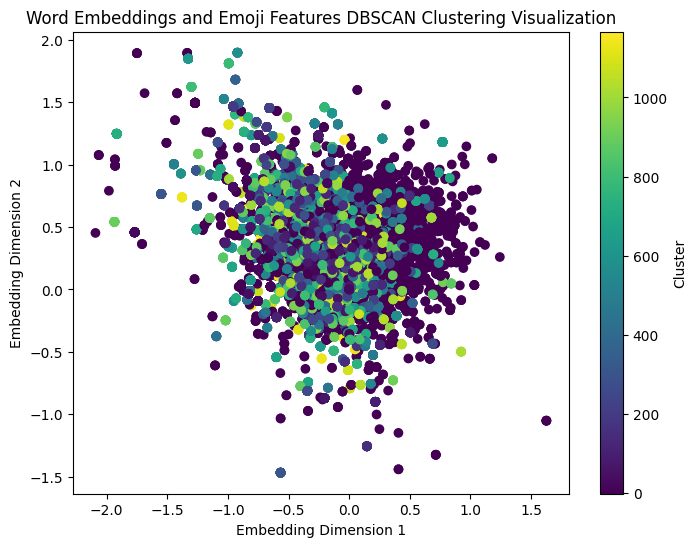

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)    │ (None, 1, 1)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_3 (LSTM)                 │ (None, 1, 64)             │          16,896 │ input_layer_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention_3 (Attention)       │ (None, 1, 64)             │               0 │ lstm_3[0][0], lstm_3[0][0] │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_3 (Concatenate)   │ (None, 1, 128)            │               0 │ lstm_3[0][0],              │
│                               │                           │                 │ attention_3[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 128)               │               0 │ concatenate_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_3 (Dropout)           │ (None, 128)               │               0 │ flatten[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_6 (Dense)               │ (None, 32)                │           4,128 │ dropout_3[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_7 (Dense)               │ (None, 2)                 │              66 │ dense_6[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 21,090 (82.38 KB)

 Trainable params: 21,090 (82.38 KB)

 Non-trainable params: 0 (0.00 B)

...

C:\Users\Janani\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\ops\nn.py:827: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


737/737 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8751 - loss: 0.3395 - val_accuracy: 0.9387 - val_loss: 0.2294
Epoch 2/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9426 - loss: 0.2217 - val_accuracy: 0.9387 - val_loss: 0.2325
Epoch 3/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9376 - loss: 0.2348 - val_accuracy: 0.9387 - val_loss: 0.2296
Epoch 4/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9414 - loss: 0.2248 - val_accuracy: 0.9387 - val_loss: 0.2314
Epoch 5/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9398 - loss: 0.2279 - val_accuracy: 0.9387 - val_loss: 0.2287
Epoch 6/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9386 - loss: 0.2303 - val_accuracy: 0.9387 - val_loss: 0.2282
Epoch 7/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9399 - loss: 0.2255 - val_accuracy: 0.9387 - val_loss: 0.2286
Epoch 8/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9388 - loss: 0.2301 - val_accuracy: 0.9387 - val_

C:\Users\Janani\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\ops\nn.py:827: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9429 - loss: 0.2163

LSTM + Attention Model Performance:
Test Accuracy: 93.87%
Confusion Matrix:
 [[   0  361]
 [   0 5532]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       361
           1       0.94      1.00      0.97      5532

    accuracy                           0.94      5893
   macro avg       0.47      0.50      0.48      5893
weighted avg       0.88      0.94      0.91      5893



C:\Users\Janani\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Janani\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Janani\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, LSTM, Dropout, Dense, Attention, Concatenate, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.cluster import DBSCAN
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Add emoji features to the DataFrame
tweets_df['hate_emoji'] = tweets_df['Clean_Tweets'].apply(lambda x: 1 if any(emoji in x for emoji in hate_emojis) else 0)
tweets_df['non_hate_emoji'] = tweets_df['Clean_Tweets'].apply(lambda x: 1 if any(emoji in x for emoji in non_hate_emojis) else 0)

# Step 2: Convert 'Word_Embedding' to a consistent 2D numpy array
X = np.array([np.array(embedding) for embedding in tweets_df['Word_Embedding']])

# Step 3: Add emoji features to the word embeddings
X_emoji_features = tweets_df[['hate_emoji', 'non_hate_emoji']].values  # Extract emoji columns
X_combined = np.concatenate([X, X_emoji_features], axis=1)  # Combine word embeddings and emoji features

# Step 4: Apply DBSCAN clustering to the word embeddings (X_combined)
eps_value = 0.5  # Maximum distance between points to be considered neighbors
min_samples_value = 5  # Minimum number of points required to form a cluster
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
X_clustered = dbscan.fit_predict(X_combined)  # This gives cluster labels or -1 for noise points

# Visualize the clustering results (first 2 dimensions for plotting)
plt.figure(figsize=(8, 6))
plt.scatter(X_combined[:, 0], X_combined[:, 1], c=X_clustered, cmap='viridis')
plt.colorbar(label='Cluster')
plt.title("Word Embeddings and Emoji Features DBSCAN Clustering Visualization")
plt.xlabel("Embedding Dimension 1")
plt.ylabel("Embedding Dimension 2")
plt.show()

# Reshape the clustered labels to match the LSTM input format
X_clustered = X_clustered.reshape((X_clustered.shape[0], 1, 1))  # Reshape to (samples, timesteps, features)

# Step 5: Prepare the labels for classification
label_encoder = LabelEncoder()
y = tweets_df['Label']
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded) 

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_clustered, y_categorical, test_size=0.2, random_state=42)

# Step 6: Define the LSTM model with Attention
input_layer = Input(shape=(X_clustered.shape[1], X_clustered.shape[2]))  # Input layer

# LSTM layer with return_sequences=True to output a sequence of vectors
lstm_out = LSTM(64, return_sequences=True)(input_layer)  # LSTM layer with 64 units

# Attention mechanism (applied over the sequence output from LSTM)
attention = Attention()([lstm_out, lstm_out])  # Apply attention to the LSTM output
attention_out = Concatenate(axis=-1)([lstm_out, attention])  # Concatenate LSTM output with attention result

# Flatten the output to match the shape of labels
flattened_out = Flatten()(attention_out)

# Dropout layer
flattened_out = Dropout(0.5)(flattened_out)

# Dense layer with ReLU activation
dense_out = Dense(32, activation='relu')(flattened_out)

# Output layer for binary classification
output_layer = Dense(2, activation='softmax')(dense_out)

# Define the model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Step 7: Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Step 8: Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Step 9: Perform predictions and evaluate the model performance
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

# Step 10: Evaluate LSTM + Attention model performance
lstm_loss, lstm_accuracy = model.evaluate(X_test, y_test)
print("\nLSTM + Attention Model Performance:")
print(f"Test Accuracy: {lstm_accuracy * 100:.2f}%")
print("Confusion Matrix:\n", confusion_matrix(np.argmax(y_test, axis=1), predicted_classes))
print("Classification Report:\n", classification_report(np.argmax(y_test, axis=1), predicted_classes))


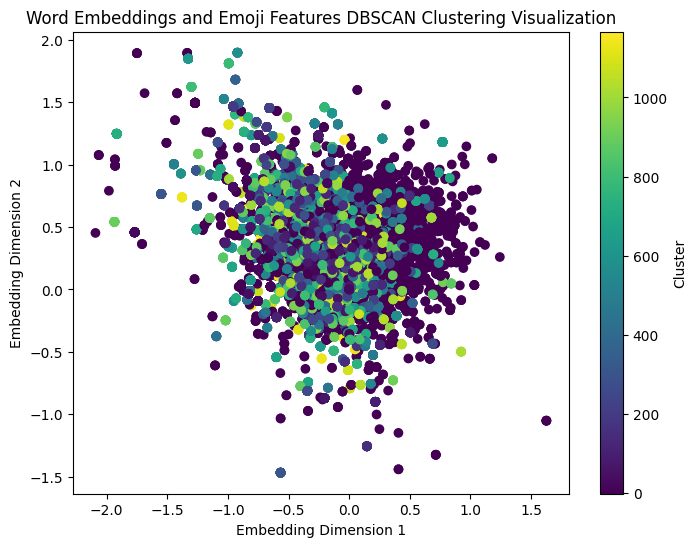

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)    │ (None, 1, 1)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bidirectional (Bidirectional) │ (None, 1, 128)            │          33,792 │ input_layer_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ attention_4 (Attention)       │ (None, 1, 128)            │               0 │ bidirectional[0][0],       │
│                               │                           │                 │ bidirectional[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_4 (Concatenate)   │ (None, 1, 256)            │               0 │ bidirectional[0][0],       │
│                               │                           │                 │ attention_4[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_1 (Flatten)           │ (None, 256)               │               0 │ concatenate_4[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_4 (Dropout)           │ (None, 256)               │               0 │ flatten_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_8 (Dense)               │ (None, 32)                │           8,224 │ dropout_4[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_9 (Dense)               │ (None, 2)                 │              66 │ dense_8[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 42,082 (164.38 KB)

 Trainable params: 42,082 (164.38 KB)

 Non-trainable params: 0 (0.00 B)

...

C:\Users\Janani\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\ops\nn.py:827: UserWarning: You are using a softmax over axis -1 of a tensor of shape (None, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


737/737 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9109 - loss: 0.2990 - val_accuracy: 0.9387 - val_loss: 0.2339
Epoch 2/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.9401 - loss: 0.2285 - val_accuracy: 0.9387 - val_loss: 0.2295
Epoch 3/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9376 - loss: 0.2355 - val_accuracy: 0.9387 - val_loss: 0.2278
Epoch 4/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9394 - loss: 0.2296 - val_accuracy: 0.9387 - val_loss: 0.2301
Epoch 5/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9382 - loss: 0.2343 - val_accuracy: 0.9387 - val_loss: 0.2286
Epoch 6/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9391 - loss: 0.2298 - val_accuracy: 0.9387 - val_loss: 0.2318
Epoch 7/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9375 - loss: 0.2336 - val_accuracy: 0.9387 - val_loss: 0.2293
Epoch 8/20
737/737 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9387 - loss: 0.2304 - val_accuracy: 0.9387 - val_

C:\Users\Janani\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\ops\nn.py:827: UserWarning: You are using a softmax over axis -1 of a tensor of shape (32, 1, 1). This axis has size 1. The softmax operation will always return the value 1, which is likely not what you intended. Did you mean to use a sigmoid instead?
  warnings.warn(


185/185 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
185/185 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9429 - loss: 0.2183

Bi-LSTM + Attention Model Performance:
Test Accuracy: 93.87%
Confusion Matrix:
 [[   0  361]
 [   0 5532]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       361
           1       0.94      1.00      0.97      5532

    accuracy                           0.94      5893
   macro avg       0.47      0.50      0.48      5893
weighted avg       0.88      0.94      0.91      5893



C:\Users\Janani\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Janani\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Janani\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dropout, Dense, Attention, Concatenate, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.cluster import DBSCAN
from sklearn.metrics import classification_report, confusion_matrix

# Step 1: Add emoji features to the DataFrame
tweets_df['hate_emoji'] = tweets_df['Clean_Tweets'].apply(lambda x: 1 if any(emoji in x for emoji in hate_emojis) else 0)
tweets_df['non_hate_emoji'] = tweets_df['Clean_Tweets'].apply(lambda x: 1 if any(emoji in x for emoji in non_hate_emojis) else 0)

# Step 2: Convert 'Word_Embedding' to a consistent 2D numpy array
X = np.array([np.array(embedding) for embedding in tweets_df['Word_Embedding']])

# Step 3: Add emoji features to the word embeddings
X_emoji_features = tweets_df[['hate_emoji', 'non_hate_emoji']].values  # Extract emoji columns
X_combined = np.concatenate([X, X_emoji_features], axis=1)  # Combine word embeddings and emoji features

# Step 4: Apply DBSCAN clustering to the word embeddings (X_combined)
eps_value = 0.5  # Maximum distance between points to be considered neighbors
min_samples_value = 5  # Minimum number of points required to form a cluster
dbscan = DBSCAN(eps=eps_value, min_samples=min_samples_value)
X_clustered = dbscan.fit_predict(X_combined)  # This gives cluster labels or -1 for noise points

# Visualize the clustering results (first 2 dimensions for plotting)
plt.figure(figsize=(8, 6))
plt.scatter(X_combined[:, 0], X_combined[:, 1], c=X_clustered, cmap='viridis')
plt.colorbar(label='Cluster')
plt.title("Word Embeddings and Emoji Features DBSCAN Clustering Visualization")
plt.xlabel("Embedding Dimension 1")
plt.ylabel("Embedding Dimension 2")
plt.show()

# Reshape the clustered labels to match the LSTM input format
X_clustered = X_clustered.reshape((X_clustered.shape[0], 1, 1))  # Reshape to (samples, timesteps, features)

# Step 5: Prepare the labels for classification
label_encoder = LabelEncoder()
y = tweets_df['Label']
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded) 

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_clustered, y_categorical, test_size=0.2, random_state=42)

# Step 6: Define the Bi-LSTM model with Attention
input_layer = Input(shape=(X_clustered.shape[1], X_clustered.shape[2]))  # Input layer

# Bi-LSTM layer with return_sequences=True to output a sequence of vectors
bi_lstm_out = Bidirectional(LSTM(64, return_sequences=True))(input_layer)  # Bi-LSTM layer with 64 units

# Attention mechanism (applied over the sequence output from Bi-LSTM)
attention = Attention()([bi_lstm_out, bi_lstm_out])  # Apply attention to the Bi-LSTM output
attention_out = Concatenate(axis=-1)([bi_lstm_out, attention])  # Concatenate Bi-LSTM output with attention result

# Flatten the output to match the shape of labels
flattened_out = Flatten()(attention_out)

# Dropout layer
flattened_out = Dropout(0.5)(flattened_out)

# Dense layer with ReLU activation
dense_out = Dense(32, activation='relu')(flattened_out)

# Output layer for binary classification
output_layer = Dense(2, activation='softmax')(dense_out)

# Define the model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Step 7: Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Step 8: Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Step 9: Perform predictions and evaluate the model performance
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

# Step 10: Evaluate Bi-LSTM + Attention model performance
bi_lstm_loss, bi_lstm_accuracy = model.evaluate(X_test, y_test)
print("\nBi-LSTM + Attention Model Performance:")
print(f"Test Accuracy: {bi_lstm_accuracy * 100:.2f}%")
print("Confusion Matrix:\n", confusion_matrix(np.argmax(y_test, axis=1), predicted_classes))
print("Classification Report:\n", classification_report(np.argmax(y_test, axis=1), predicted_classes))

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dropout, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import math

In [62]:
# Step 1: Add emoji features to the DataFrame
tweets_df['hate_emoji'] = tweets_df['Clean_Tweets'].apply(lambda x: 1 if any(emoji in x for emoji in hate_emojis) else 0)
tweets_df['non_hate_emoji'] = tweets_df['Clean_Tweets'].apply(lambda x: 1 if any(emoji in x for emoji in non_hate_emojis) else 0)

# Step 2: Convert 'Word_Embedding' to a consistent 2D numpy array
X = np.array([np.array(embedding) for embedding in tweets_df['Word_Embedding']])


In [63]:
# Step 3: Add emoji features to the word embeddings
X_emoji_features = tweets_df[['hate_emoji', 'non_hate_emoji']].values  # Extract emoji columns
X_combined = np.concatenate([X, X_emoji_features], axis=1)  # Combine word embeddings and emoji features

In [64]:
# Step 4: Implement Quantum Clustering (Optional - you can skip this part if you want)
def euclidean_distance(point1, point2):
    """Compute Euclidean distance."""
    return np.sum((np.array(point1) - np.array(point2)) ** 2)

def gaussian_potential(data, sigma):
    """Compute Gaussian potentials."""
    potentials = []
    for i, point_i in enumerate(data):
        potential = 0
        for j, point_j in enumerate(data):
            if i != j:
                distance_squared = euclidean_distance(point_i, point_j)
                gaussian_value = math.exp(-distance_squared / (2 * sigma ** 2))
                potential += gaussian_value
        potentials.append(potential)
    return np.array(potentials)

def compute_laplacian(grid, h):
    """Compute the Laplacian."""
    laplacian = []
    n = len(grid)
    for i in range(n):
        if 0 < i < n - 1:
            value = (grid[i - 1] - 2 * grid[i] + grid[i + 1]) / h ** 2
        else:
            value = 0  # Boundary conditions
        laplacian.append(value)
    return np.array(laplacian)

def schrodinger_solver(potentials, h):
    """Solve Schrödinger equation."""
    psi = np.ones(len(potentials))  # Initial wavefunction
    m, hbar = 1.0, 1.0
    for iteration in range(3):  # Adjust iterations for convergence
        laplacian = compute_laplacian(psi, h)
        for i in range(len(potentials)):
            psi[i] = psi[i] + 0.1 * (-hbar ** 2 / (2 * m) * laplacian[i] + potentials[i] * psi[i])
    return psi

def quantum_clustering(data, sigma, h):
    """Perform Quantum Clustering."""
    potentials = gaussian_potential(data, sigma)
    psi = schrodinger_solver(potentials, h)
    probabilities = np.abs(psi) ** 2
    threshold = 0.5 * np.max(probabilities)
    clusters = [i for i, prob in enumerate(probabilities) if prob > threshold]
    return clusters, potentials, psi

In [65]:
sigma = 1.0  # Gaussian smoothing parameter
h = 1.0  # Grid spacing

In [66]:
clusters, potentials, psi = quantum_clustering(X_combined, sigma, h)

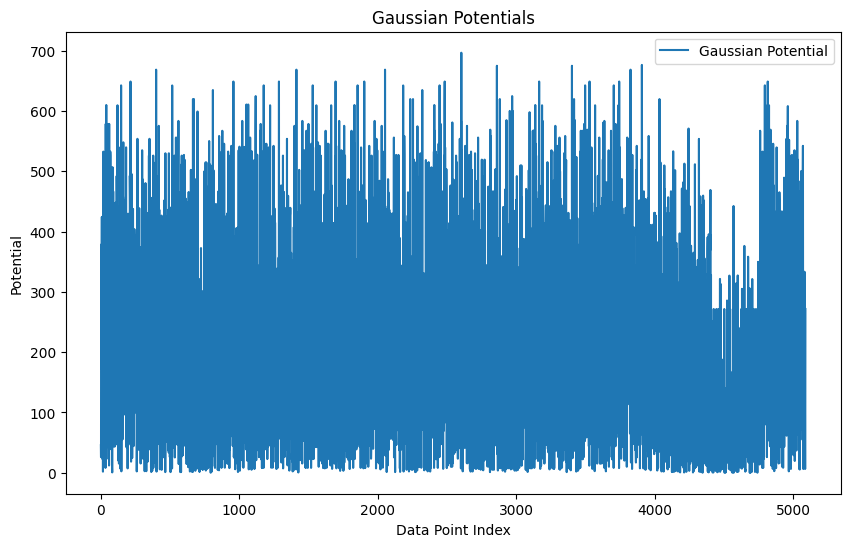

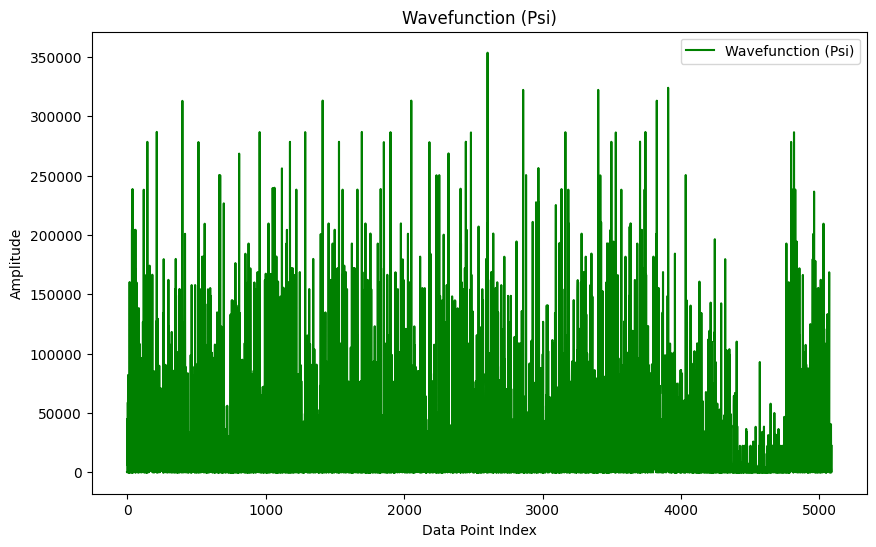

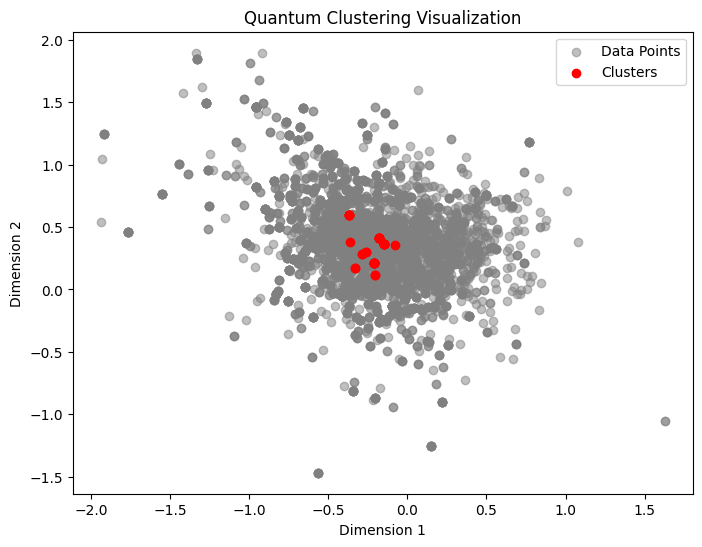

In [67]:
# Step 5: Visualize Quantum Clustering results (optional)
plt.figure(figsize=(10, 6))
plt.plot(potentials, label="Gaussian Potential")
plt.title("Gaussian Potentials")
plt.xlabel("Data Point Index")
plt.ylabel("Potential")
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(psi, label="Wavefunction (Psi)", color="green")
plt.title("Wavefunction (Psi)")
plt.xlabel("Data Point Index")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

# Visualize clusters (using the first two dimensions)
plt.figure(figsize=(8, 6))
plt.scatter(X_combined[:, 0], X_combined[:, 1], c='gray', alpha=0.5, label='Data Points')
plt.scatter(X_combined[clusters, 0], X_combined[clusters, 1], c='red', label='Clusters')
plt.title("Quantum Clustering Visualization")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()
plt.show()

In [68]:
# Step 6: Prepare the labels for classification
X_clustered = np.zeros((len(X_combined), 1, 1))  # Initialize clustered data
X_clustered[clusters] = 1  # Assign cluster labels as features

In [69]:
label_encoder = LabelEncoder()
y = tweets_df['Label']
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

In [70]:
# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_clustered, y_categorical, test_size=0.2, random_state=42)

In [71]:
# Step 7: Define and Train Bi-LSTM model (without Attention mechanism)
input_layer = Input(shape=(X_clustered.shape[1], X_clustered.shape[2]))  # Input layer
bi_lstm_out = Bidirectional(LSTM(64, return_sequences=False))(input_layer)  # Bi-LSTM layer without attention

# Dropout layer to prevent overfitting
dropout_out = Dropout(0.5)(bi_lstm_out)

# Dense layer with ReLU activation
dense_out = Dense(32, activation='relu')(dropout_out)

# Output layer for binary classification
output_layer = Dense(2, activation='softmax')(dense_out)

# Define the model
model = Model(inputs=input_layer, outputs=output_layer)

In [72]:
# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

In [73]:
# Print model summary
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 1, 1)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 128)                 │          33,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 2)                   │              66 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 37,986 (148.38 KB)

 Trainable params: 37,986 (148.38 KB)

 Non-trainable params: 0 (0.00 B)

In [74]:
# Step 8: Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.8965 - loss: 0.5026 - val_accuracy: 0.9352 - val_loss: 0.2403
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9370 - loss: 0.2368 - val_accuracy: 0.9352 - val_loss: 0.2398
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9372 - loss: 0.2374 - val_accuracy: 0.9352 - val_loss: 0.2405
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9408 - loss: 0.2267 - val_accuracy: 0.9352 - val_loss: 0.2398
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9404 - loss: 0.2263 - val_accuracy: 0.9352 - val_loss: 0.2396
Epoch 6/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9442 - loss: 0.2177 - val_accuracy: 0.9352 - val_loss: 0.2398
Epoch 7/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9360 - loss: 0.2381 - val_accuracy: 0.9352 - val_loss: 0.2396
Epoch 8/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9399 - loss: 0.2285 - val_accuracy: 

In [75]:
# Step 9: Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9320 - loss: 0.2479
Test Accuracy: 93.52%


In [76]:
# Step 10: Perform predictions and evaluate the model performance
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

# Step 11: Evaluate Bi-LSTM model performance
bi_lstm_loss, bi_lstm_accuracy = model.evaluate(X_test, y_test)
print("\nBi-LSTM Model Performance:")
print(f"Test Accuracy: {bi_lstm_accuracy * 100:.2f}%")
print("Confusion Matrix:\n", confusion_matrix(np.argmax(y_test, axis=1), predicted_classes))
print("Classification Report:\n", classification_report(np.argmax(y_test, axis=1), predicted_classes))

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9320 - loss: 0.2479

Bi-LSTM Model Performance:
Test Accuracy: 93.52%
Confusion Matrix:
 [[  0  66]
 [  0 952]]
Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00        66
           1       0.94      1.00      0.97       952

    accuracy                           0.94      1018
   macro avg       0.47      0.50      0.48      1018
weighted avg       0.87      0.94      0.90      1018



C:\Users\Janani\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Janani\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Janani\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average,

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dropout, Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import math
import pennylane as qml

# Step 1: Add emoji features to the DataFrame
tweets_df['hate_emoji'] = tweets_df['Clean_Tweets'].apply(lambda x: 1 if any(emoji in x for emoji in hate_emojis) else 0)
tweets_df['non_hate_emoji'] = tweets_df['Clean_Tweets'].apply(lambda x: 1 if any(emoji in x for emoji in non_hate_emojis) else 0)

# Step 2: Convert 'Word_Embedding' to a consistent 2D numpy array
X = np.array([np.array(embedding) for embedding in tweets_df['Word_Embedding']])

# Step 3: Add emoji features to the word embeddings
X_emoji_features = tweets_df[['hate_emoji', 'non_hate_emoji']].values  # Extract emoji columns
X_combined = np.concatenate([X, X_emoji_features], axis=1)  # Combine word embeddings and emoji features

# Step 4: Define a Quantum Variational Circuit
dev = qml.device("default.qubit", wires=2)

@qml.qnode(dev)
def variational_circuit(x, weights):
    """A simple quantum variational circuit."""
    qml.RX(x[0], wires=0)
    qml.RY(x[1], wires=1)
    qml.CNOT(wires=[0, 1])
    qml.RZ(weights[0], wires=1)
    return qml.expval(qml.PauliZ(0))  # Measure the first qubit

# Step 5: Quantum Feature Extraction - Using the quantum circuit
def extract_quantum_features(data, weights):
    quantum_features = []
    for sample in data:
        feature = variational_circuit(sample, weights)
        quantum_features.append(feature)
    return np.array(quantum_features)

# Step 6: Optional Quantum Clustering (not required for the hybrid quantum-BiLSTM model)
def quantum_clustering(data, sigma, h):
    potentials = gaussian_potential(data, sigma)
    psi = schrodinger_solver(potentials, h)
    probabilities = np.abs(psi) ** 2
    threshold = 0.5 * np.max(probabilities)
    clusters = [i for i, prob in enumerate(probabilities) if prob > threshold]
    return clusters, potentials, psi

sigma = 1.0
h = 1.0

# Step 7: Extract quantum features and combine them with the existing data
quantum_features = extract_quantum_features(X_combined, np.random.rand(1))

# Combine classical and quantum features
X_final = np.concatenate([X_combined, quantum_features.reshape(-1, 1)], axis=1)

# Step 8: Prepare the labels for classification
label_encoder = LabelEncoder()
y = tweets_df['Label']
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Step 9: Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_final, y_categorical, test_size=0.2, random_state=42)

# Step 10: Define and Train Bi-LSTM model with Quantum Features
input_layer = Input(shape=(X_train.shape[1],))  # Input layer with combined features (classical + quantum)
bi_lstm_out = Bidirectional(LSTM(64, return_sequences=False))(input_layer)  # Bi-LSTM layer

# Dropout layer to prevent overfitting
dropout_out = Dropout(0.5)(bi_lstm_out)

# Dense layer with ReLU activation
dense_out = Dense(32, activation='relu')(dropout_out)

# Output layer for binary classification (e.g., hate vs non-hate)
output_layer = Dense(2, activation='softmax')(dense_out)

# Define the model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Step 11: Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Step 12: Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Step 13: Perform predictions and evaluate the model performance
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

# Step 14: Evaluate Bi-LSTM model performance
bi_lstm_loss, bi_lstm_accuracy = model.evaluate(X_test, y_test)
print("\nBi-LSTM Model Performance:")
print(f"Test Accuracy: {bi_lstm_accuracy * 100:.2f}%")
print("Confusion Matrix:\n", confusion_matrix(np.argmax(y_test, axis=1), predicted_classes))
print("Classification Report:\n", classification_report(np.argmax(y_test, axis=1), predicted_classes))


ValueError: Input 0 of layer "bidirectional" is incompatible with the layer: expected ndim=3, found ndim=2. Full shape received: (None, 53)

In [27]:
pip install pennylane

   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   ---------------- ----------------------- 0.8/1.9 MB 5.6 MB/s eta 0:00:01
   ---------------------------- ----------- 1.3/1.9 MB 3.7 MB/s eta 0:00:01
   ---------------------------------------- 1.9/1.9 MB 3.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/930.0 kB ? eta -:--:--
   ---------------------- ----------------- 524.3/930.0 kB 2.4 MB/s eta 0:00:01
   ---------------------------------------- 930.0/930.0 kB 3.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ------- -------------------------------- 1.0/5.5 MB 6.3 MB/s eta 0:00:01
   ------------- -------------------------- 1.8/5.5 MB 4.0 MB/s eta 0:00:01
   ------------------ --------------------- 2.6/5.5 MB 4.1 MB/s eta 0:00:01
   -------------------------- ------------- 3.7/5.5 MB 4.3 MB/s eta 0:00:01
   -------------------------------- ------- 4.5/5.5 MB 4.2 MB/s eta 0:00:01
   --------------------

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, confusion_matrix
import math
import tensorflow as tf
import pennylane as qml

# Quantum Variational functions
def quantum_circuit(inputs):
    """Quantum circuit for feature encoding using Pennylane."""
    num_qubits = len(inputs)
    dev = qml.device("default.qubit", wires=num_qubits)
    
    @qml.qnode(dev)
    def circuit(inputs):
        for i in range(num_qubits):
            qml.RX(inputs[i], wires=i)  # Rotate each qubit by the input value
        return [qml.expval(qml.PauliZ(i)) for i in range(num_qubits)]
    
    return circuit(inputs)

def quantum_variational(inputs):
    """Apply quantum variational for each data point."""
    quantum_features = []
    for input_data in inputs:
        quantum_features.append(quantum_circuit(input_data))
    return np.array(quantum_features)

# Step 1: Add emoji features to the DataFrame (Example)
hate_emojis = ['💢', '💥']  # Sample hate emojis (update with actual ones)
non_hate_emojis = ['😊', '👍']  # Sample non-hate emojis (update with actual ones)

# Example DataFrame setup (you'll need to load your actual `tweets_df` here)
# tweets_df['Clean_Tweets'] = your_cleaned_tweets
# tweets_df['Word_Embedding'] = your_word_embeddings
tweets_df['hate_emoji'] = tweets_df['Clean_Tweets'].apply(lambda x: 1 if any(emoji in x for emoji in hate_emojis) else 0)
tweets_df['non_hate_emoji'] = tweets_df['Clean_Tweets'].apply(lambda x: 1 if any(emoji in x for emoji in non_hate_emojis) else 0)

# Step 2: Convert 'Word_Embedding' to a consistent 2D numpy array
X = np.array([np.array(embedding) for embedding in tweets_df['Word_Embedding']])

# Step 3: Add emoji features to the word embeddings
X_emoji_features = tweets_df[['hate_emoji', 'non_hate_emoji']].values  # Extract emoji columns
X_combined = np.concatenate([X, X_emoji_features], axis=1)  # Combine word embeddings and emoji features

# Step 4: Apply Quantum Variational Encoding
quantum_features = quantum_variational(X_combined)

# Combine Quantum Features with Classical Features
X_combined_with_quantum = np.concatenate([X_combined, quantum_features], axis=1)

# Step 5: Prepare the labels for classification
label_encoder = LabelEncoder()
y = tweets_df['Label']
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_combined_with_quantum, y_categorical, test_size=0.2, random_state=42)

# Step 6: Define and Train Bi-LSTM model with Quantum Features
input_layer = Input(shape=(X_train.shape[1],))  # Input layer with combined features (classical + quantum)

# Reshape input to (batch_size, 1, num_features) to add a time step dimension
reshaped_input = tf.keras.layers.Reshape((1, X_train.shape[1]))(input_layer)

bi_lstm_out = Bidirectional(LSTM(64, return_sequences=False))(reshaped_input)  # Bi-LSTM layer

# Dropout layer to prevent overfitting
dropout_out = Dropout(0.5)(bi_lstm_out)

# Dense layer with ReLU activation
dense_out = Dense(32, activation='relu')(dropout_out)

# Output layer for binary classification
output_layer = Dense(2, activation='softmax')(dense_out)

# Define the model
model = Model(inputs=input_layer, outputs=output_layer)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

# Step 7: Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))

# Step 8: Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

# Step 9: Perform predictions and evaluate the model performance
predictions = model.predict(X_test)
predicted_classes = np.argmax(predictions, axis=1)

# Step 10: Evaluate Bi-LSTM model performance
bi_lstm_loss, bi_lstm_accuracy = model.evaluate(X_test, y_test)
print("\nBi-LSTM Model Performance:")
print(f"Test Accuracy: {bi_lstm_accuracy * 100:.2f}%")
print("Confusion Matrix:\n", confusion_matrix(np.argmax(y_test, axis=1), predicted_classes))
print("Classification Report:\n", classification_report(np.argmax(y_test, axis=1), predicted_classes))

# Optional: Visualize the training history
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='upper left')
plt.show()


ValueError: maximum supported dimension for an ndarray is 32, found 52